<a href="https://colab.research.google.com/github/Lekanggy/MLrepo/blob/main/POS_Tagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install contractions emoji

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi
from google.colab import files
import os


if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Please upload your kaggle.json file. You can get it from your Kaggle account settings.")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

    # Ensure the .kaggle directory exists
    os.makedirs('/root/.kaggle', exist_ok=True)

    # Move the uploaded file to the correct directory
    # Assuming the uploaded file is named 'kaggle.json'
    if 'kaggle.json' in uploaded:
        os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
        # Set permissions
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        print("Kaggle.json uploaded and configured successfully.")
    else:
        print("Error: kaggle.json not found in uploaded files. Please ensure you upload the correct file.")
else:
    print("Kaggle.json already exists and is configured.")
# --- Kaggle Authentication Setup (end) ---


# Authenticate with Kaggle API
api = KaggleApi()
# The api.authenticate() call is removed as it's causing a NameError on failure
# The KaggleApi() constructor should automatically pick up credentials from ~/.kaggle/kaggle.json

# Download the dataset
api.dataset_download_files('kazanova/sentiment140', path='./sentiment140', unzip=True)



Kaggle.json already exists and is configured.
Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import contractions
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from tqdm import tqdm

import re
import os
import emoji

# Disable unnecessary spaCy components for maximum speed during POS tagging
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [ ]:
# Download necessary NLTK data
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Enable tqdm for pandas apply on large datasets
tqdm.pandas()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


#Downlaod Dataset

In [ ]:
# Read the CSV into pandas
df = pd.read_csv('./sentiment140/training.1600000.processed.noemoticon.csv',
                  encoding='latin-1',
                  header=None)

# Assign column names (dataset has no header)
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

# Map target: 0 = Negative, 4 = Positive (converting 4 to 1 for standard binary format)
df['target'] = df['target'].map({0: 0, 4: 1})
df['sentiment'] = df['target'].map({0: 'Negative', 1: 'Positive'})

In [ ]:
print("--- Dataset Info ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

print(f"Shape: {df.shape}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   target     1600000 non-null  int64 
 1   ids        1600000 non-null  int64 
 2   date       1600000 non-null  object
 3   flag       1600000 non-null  object
 4   user       1600000 non-null  object
 5   text       1600000 non-null  object
 6   sentiment  1600000 non-null  object
dtypes: int64(2), object(5)
memory usage: 85.4+ MB

--- First 5 Rows ---


,target,ids,date,flag,user,text,sentiment
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,Negative
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,Negative
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,Negative
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",Negative


Shape: (1600000, 7)


From the `df.info()` output, we can observe that the dataset consists of exactly **1,600,000 entries** (rows). Crucially, all columns (`target`, `ids`, `date`, `flag`, `user`, `text`, `sentiment`) show **1,600,000 non-null values**, indicating that there are **no missing values** across any of the features in this dataset. The `target` and `ids` columns are of integer type, while `date`, `flag`, `user`, `text`, and the newly added `sentiment` columns are of object type (string).

#Data analysis and Exploratory

###Plot class Distribution


--- Class Distribution ---
sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64


/tmp/ipykernel_8892/553510926.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette=['#FF6B6B', '#4ECDC4'])


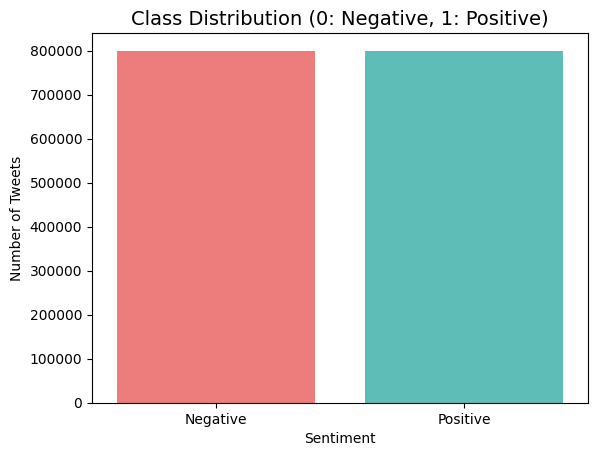

In [ ]:
print("\n--- Class Distribution ---")
print(df['sentiment'].value_counts())

plt.figure()
sns.countplot(data=df, x='sentiment', palette=['#FF6B6B', '#4ECDC4'])
plt.title('Class Distribution (0: Negative, 1: Positive)', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

The class distribution plot clearly shows that the dataset is perfectly balanced, with an equal number of **800,000 negative** tweets and **800,000 positive** tweets. This ensures that models trained on this data will not be biased towards one sentiment class.

In [ ]:
# Calculate character and word lengths BEFORE cleaning
df['char_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\n--- Tweet Length Statistics ---")
print(df[['char_length', 'word_count']].describe())


--- Tweet Length Statistics ---
        char_length    word_count
count  1.600000e+06  1.600000e+06
mean   7.409011e+01  1.317615e+01
std    3.644114e+01  6.957978e+00
min    6.000000e+00  1.000000e+00
25%    4.400000e+01  7.000000e+00
50%    6.900000e+01  1.200000e+01
75%    1.040000e+02  1.900000e+01
max    3.740000e+02  6.400000e+01


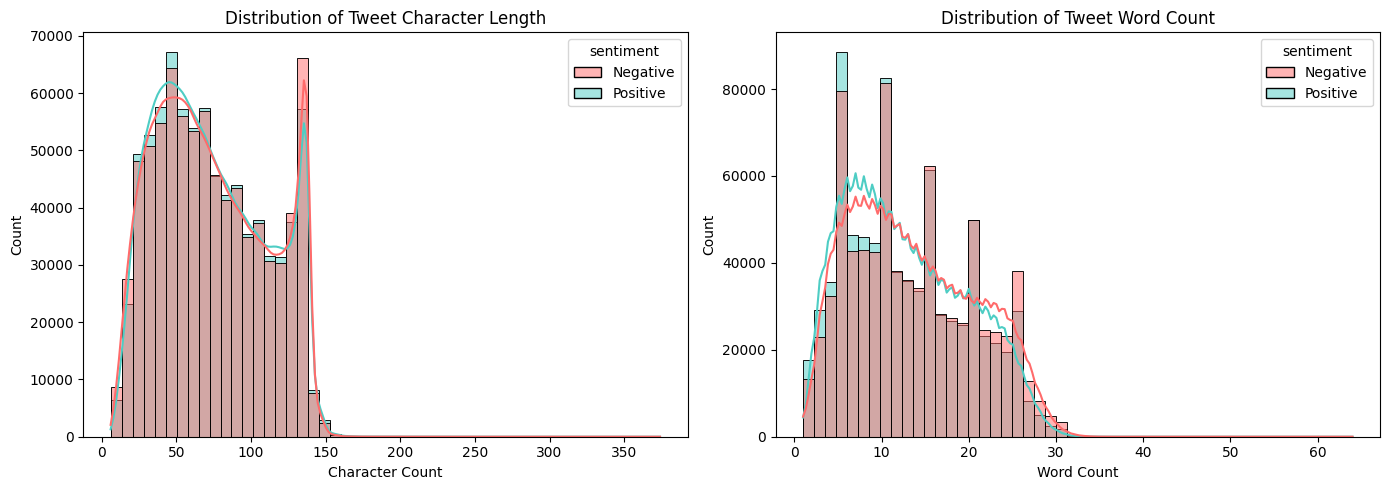

In [ ]:
# Plot character length and words distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='char_length', hue='sentiment', bins=50, kde=True, ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Distribution of Tweet Character Length')
axes[0].set_xlabel('Character Count')

sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, kde=True, ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Distribution of Tweet Word Count')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

Both sentiments share similar distributions. Character length peaks at 40–70 and around 140 chars possibly due to Twitter limit. Word count peaks at 5–10 words then drops. This clearly suggested that length does not clearly distinguish positive from negative sentiment.

In [ ]:
# Helper functions to extract specific noisy elements
def extract_hashtags(text):
    return re.findall(r'#\w+', text.lower())

def extract_mentions(text):
    return re.findall(r'@\w+', text.lower())

def extract_emojis(text):
    # emoji.distinct_emoji_list returns actual emoji characters
    return [char for char in text if char in emoji.EMOJI_DATA]


# Flatten lists and count frequencies
def get_top_items(column, n=15):
    all_items = [item for sublist in df[column] for item in sublist]
    if not all_items:
        return []
    return Counter(all_items).most_common(n)

In [ ]:
df['hashtags'] = df['text'].apply(extract_hashtags)
df['mentions'] = df['text'].apply(extract_mentions)
df['emojis'] = df['text'].apply(extract_emojis)

top_hashtags = get_top_items('hashtags')
top_mentions = get_top_items('mentions')
top_emojis = get_top_items('emojis')

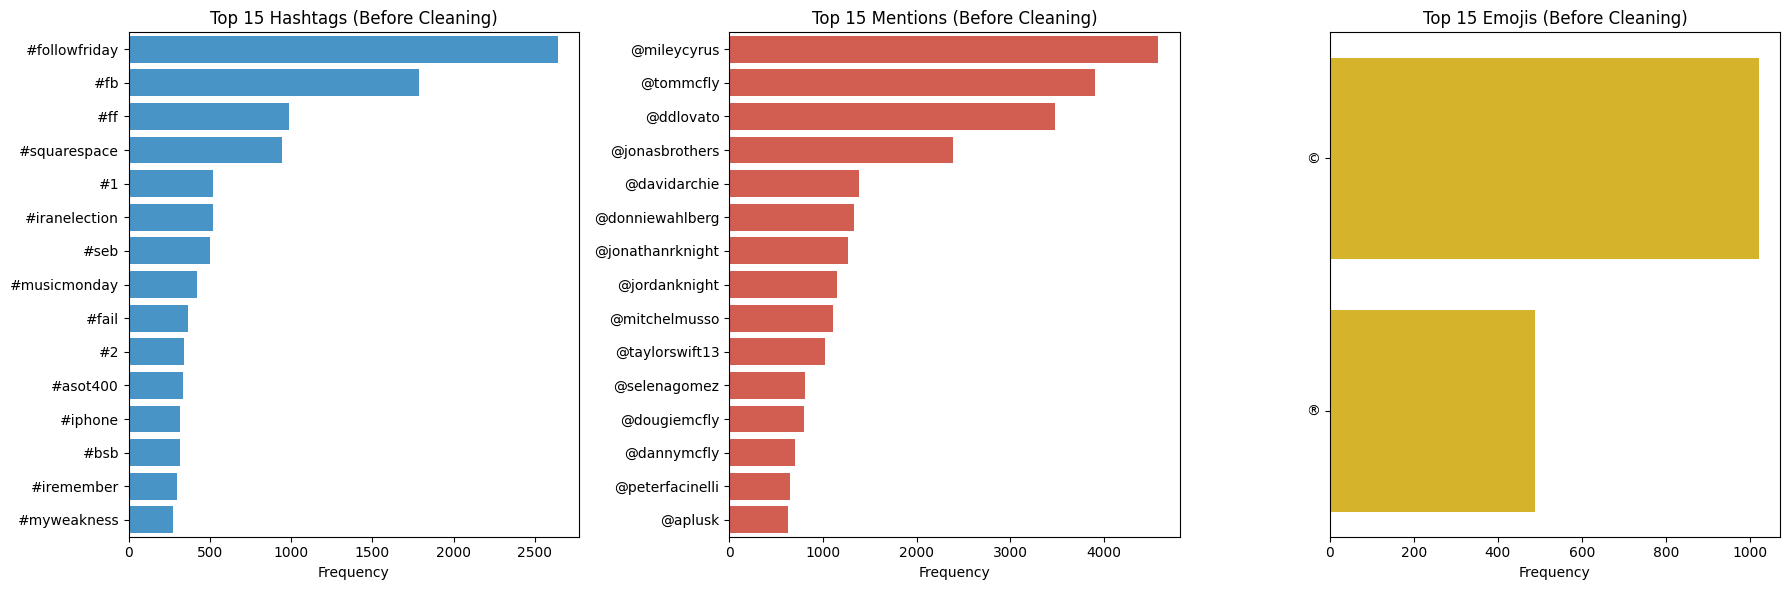

In [ ]:

# Plot the distribution of the top items
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top Hashtags
if top_hashtags:
    sns.barplot(x=[x[1] for x in top_hashtags], y=[x[0] for x in top_hashtags], ax=axes[0], color='#3498DB')
    axes[0].set_title('Top 15 Hashtags (Before Cleaning)')
    axes[0].set_xlabel('Frequency')

# Top Mentions
if top_mentions:
    sns.barplot(x=[x[1] for x in top_mentions], y=[x[0] for x in top_mentions], ax=axes[1], color='#E74C3C')
    axes[1].set_title('Top 15 Mentions (Before Cleaning)')
    axes[1].set_xlabel('Frequency')

# Top Emojis
if top_emojis:
    sns.barplot(x=[x[1] for x in top_emojis], y=[x[0] for x in top_emojis], ax=axes[2], color='#F1C40F')
    axes[2].set_title('Top 15 Emojis (Before Cleaning)')
    axes[2].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### Observation on Noisy Elements (Hashtags, Mentions, Emojis)

The distributions of noisy elements reveal distinct patterns:

*   **Hashtags**: The most frequent hashtags are often generic or related to common Twitter practices like `#followfriday` and `#fb`. This suggests a mix of content-related and platform-specific usage.
*   **Mentions**: A significant portion of mentions targets popular figures and celebrities (e.g., `@mileycyrus`, `@tommcfly`), indicating that many tweets are interactions with public personalities.
*   **Emojis**: The observed 'emojis' are predominantly copyright (©) and registered (®) symbols, appearing less frequently than hashtags and mentions. This might suggest either a low prevalence of standard pictorial emojis in this specific dataset or a need for refinement in emoji extraction to focus on pictorial representations.

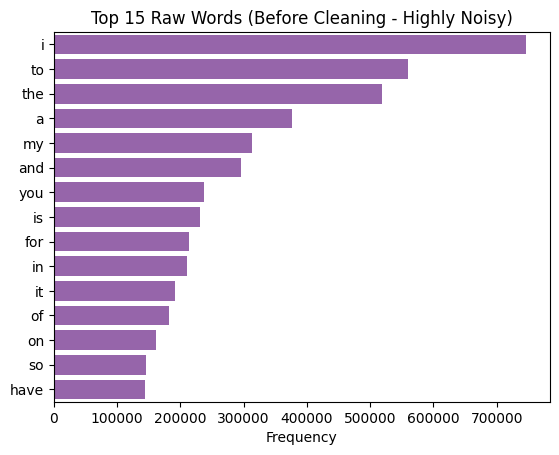

In [ ]:
# Quick Word Frequency (Raw)
raw_words = [word.lower() for text in df['text'] for word in text.split()]
top_raw_words = Counter(raw_words).most_common(15)

plt.figure()
sns.barplot(x=[x[1] for x in top_raw_words], y=[x[0] for x in top_raw_words], color='#9B59B6')
plt.title('Top 15 Raw Words (Before Cleaning - Highly Noisy)')
plt.xlabel('Frequency')
plt.show()

In [ ]:
# Calculating the percentage of tweets containing specific noise types
total_tweets = len(df)

noise_patterns = {
    "URLs": r'http\S+|www\.\S+',
    "Mentions (@)": r'@\w+',
    "Hashtags (#)": r'#\w+',
    "Multiple Punctuation (!! ??)": r'(\?{2,})|(!{2,})',
    "Elongated Words (e.g., soooo)": r'\b\w*(\w)\1{2,}\w*\b',  # Matches 3+ repeated chars
    "Contractions (e.g., I'm, can't)": r"\w+'\w+",
    "Numbers/Digits": r'\b\d+\b'
}

print("\n--- Noise Distribution in Dataset ---")
for noise_type, pattern in noise_patterns.items():
    # Count how many tweets contain at least one instance of the pattern
    count = df['text'].str.contains(pattern, regex=True, na=False).sum()
    percentage = (count / total_tweets) * 100
    print(f"{noise_type:<30} | {count:>8} tweets | {percentage:.2f}% of dataset")



--- Noise Distribution in Dataset ---
URLs                           |    75739 tweets | 4.73% of dataset
Mentions (@)                   |   738493 tweets | 46.16% of dataset
Hashtags (#)                   |    35847 tweets | 2.24% of dataset


/tmp/ipykernel_8892/1841691103.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = df['text'].str.contains(pattern, regex=True, na=False).sum()


Multiple Punctuation (!! ??)   |   137913 tweets | 8.62% of dataset
Elongated Words (e.g., soooo)  |   150194 tweets | 9.39% of dataset
Contractions (e.g., I'm, can't) |   472468 tweets | 29.53% of dataset
Numbers/Digits                 |   174470 tweets | 10.90% of dataset


In [ ]:
# Display a sample of messy tweets
print("\n--- Sample of Highly Noisy Tweets ---")
# Find tweets with at least 3 different types of noise
df['noise_count'] = sum(df['text'].str.contains(pat, regex=True, na=False).astype(int) for pat in noise_patterns.values())
messy_samples = df[df['noise_count'] >= 3].sample(5, random_state=42)
for idx, row in messy_samples.iterrows():
    print(f"\n[Target: {row['sentiment']}]")
    print(f"Text: {row['text']}")


--- Sample of Highly Noisy Tweets ---


/tmp/ipykernel_8892/765554901.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['noise_count'] = sum(df['text'].str.contains(pat, regex=True, na=False).astype(int) for pat in noise_patterns.values())
/tmp/ipykernel_8892/765554901.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['noise_count'] = sum(df['text'].str.contains(pat, regex=True, na=False).astype(int) for pat in noise_patterns.values())



[Target: Negative]
Text: @Dez4jc Awww... sorry...  I'll do better... I love you Mommy...

[Target: Positive]
Text: @dorkydeanna s'ok hope you get home soon  I knowww I want that album sooo bad! They keep talking bout it as well which doesn't help!

[Target: Negative]
Text: @emstar666 It was for a little! I was doing free latte Mondays a few weeks in a row  how's NYC!?

[Target: Positive]
Text: @junsikat yeah, I'm sure you're pooped!!! Sweet dreams schatz! 

[Target: Negative]
Text: @G_Money69 I'm not very Twitter savvy. Just saw your message from May 19. We are #16 in GA!  Going in the wrong direction! 


#**Text Preprocessing Pipeline**

In [ ]:
#Text preprocessing Helper
class TwitterPreprocessor:
    """
    A modular text preprocessing pipeline specifically designed for noisy Twitter data.
    """
    def __init__(self, keep_hashtags=False, remove_emojis=True):
        self.keep_hashtags = keep_hashtags
        self.remove_emojis_flag = remove_emojis

        # Initialize NLTK tools once for efficiency
        self.stop_words = set(stopwords.words('english'))
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()

    def _fix_contractions(self, text: str) -> str:
        """Expand contractions (e.g., "don't" -> "do not") using the contractions library."""
        return contractions.fix(text)

    def _lowercase(self, text: str) -> str:
        return text.lower()

    def _remove_urls(self, text: str) -> str:
        return re.sub(r'http\S+|www\.\S+', '', text)

    def _remove_mentions(self, text: str) -> str:
        return re.sub(r'@\w+', '', text)

    def _remove_hashtags(self, text: str) -> str:
        if self.keep_hashtags:
            # Keep the word, remove the '#' symbol
            return text.replace('#', '')
        # Remove the hashtag and the word entirely
        return re.sub(r'#\w+', '', text)

    def _remove_emojis(self, text: str) -> str:
        if self.remove_emojis_flag:
            return emoji.replace_emoji(text, replace='')
        return text

    def _reduce_repeated_chars(self, text: str) -> str:
        """Reduce elongated words (e.g., 'yesssss' -> 'yes', 'goood' -> 'goo')."""
        # Matches any character repeated 3 or more times and reduces to 1
        return re.sub(r'(.)\1{2,}', r'\1', text)

    def _remove_punctuation_numbers_special(self, text: str) -> str:
        """Remove all punctuation, numbers, and special characters (keeping only letters and spaces)."""
        return re.sub(r'[^a-z\s]', '', text)

    def _remove_extra_whitespace(self, text: str) -> str:
        return re.sub(r'\s+', ' ', text).strip()

    def _tokenize(self, text: str) -> list:
        return word_tokenize(text)

    def _remove_stopwords(self, tokens: list) -> list:
        return [word for word in tokens if word not in self.stop_words]

    def _apply_stemming(self, tokens: list) -> list:
        return [self.stemmer.stem(word) for word in tokens]

    def _apply_lemmatization(self, tokens: list) -> list:
        return [self.lemmatizer.lemmatize(word) for word in tokens]

    def _basic_clean(self, text: str) -> str:
        """Version A: Basic cleaning pipeline returning a cleaned string."""
        text = self._fix_contractions(text)
        text = self._lowercase(text)
        text = self._remove_urls(text)
        text = self._remove_mentions(text)
        text = self._remove_hashtags(text)
        text = self._remove_emojis(text)
        text = self._reduce_repeated_chars(text)
        text = self._remove_punctuation_numbers_special(text)
        text = self._remove_extra_whitespace(text)
        return text

    def preprocess_basic(self, text: str) -> str:
        """Version A Pipeline"""
        return self._basic_clean(text)

    def preprocess_stem(self, text: str) -> str:
        """Version B Pipeline: Basic + Stopwords + Stemming"""
        cleaned_text = self._basic_clean(text)
        tokens = self._tokenize(cleaned_text)
        tokens = self._remove_stopwords(tokens)
        tokens = self._apply_stemming(tokens)
        return ' '.join(tokens)

    def preprocess_lemma(self, text: str) -> str:
        """Version C Pipeline: Basic + Stopwords + Lemmatization"""
        cleaned_text = self._basic_clean(text)
        tokens = self._tokenize(cleaned_text)
        tokens = self._remove_stopwords(tokens)
        tokens = self._apply_lemmatization(tokens)
        return ' '.join(tokens)


In [ ]:
# Set keep_hashtags=True if you want to keep the hashtag text without the '#'
preprocessor = TwitterPreprocessor(keep_hashtags=False, remove_emojis=True)

print("Processing Version A (Basic Cleaning)...")
df['Version_A_Basic'] = df['text'].progress_apply(preprocessor.preprocess_basic)


Processing Version A (Basic Cleaning)...


100%|██████████| 1600000/1600000 [02:37<00:00, 10153.05it/s]


In [ ]:
print("Processing Version B (Stemming)...")
df['Version_B_Stem'] = df['text'].progress_apply(preprocessor.preprocess_stem)


Processing Version B (Stemming)...


100%|██████████| 1600000/1600000 [09:18<00:00, 2864.71it/s]


In [ ]:
print("Processing Version C (Lemmatization)...")
df['Version_C_Lemma'] = df['text'].progress_apply(preprocessor.preprocess_lemma)


Processing Version C (Lemmatization)...


100%|██████████| 1600000/1600000 [06:23<00:00, 4173.35it/s]


In [ ]:
# Display the results
print("\n--- Comparison of Preprocessing Versions ---")
comparison_cols = ['text', 'Version_A_Basic', 'Version_B_Stem', 'Version_C_Lemma']
display(df[comparison_cols].head(10))


--- Comparison of Preprocessing Versions ---


,text,Version_A_Basic,Version_B_Stem,Version_C_Lemma
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",aw that is a bummer you shoulda got david carr...,aw bummer shoulda got david carr third day,aw bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,is upset that he cannot update his facebook by...,upset updat facebook text might cri result sch...,upset update facebook texting might cry result...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,dive mani time ball manag save rest go bound,dived many time ball managed save rest go bound
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire,whole body feel itchy like fire
4,"@nationwideclass no, it's not behaving at all....",no it is not behaving at all i am mad why am i...,behav mad see,behaving mad see
5,@Kwesidei not the whole crew,not the whole crew,whole crew,whole crew
6,Need a hug,need a hug,need hug,need hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...,hey long time see ye rain bit bit lol fine thank,hey long time see yes rain bit bit lol fine th...
8,@Tatiana_K nope they didn't have it,nope they did not have it,nope,nope
9,@twittera que me muera ?,que me muera,que muera,que muera


#**Part-of-Speech (POS) Tagging**

In [ ]:
#POS Modular class
class POSAnalyzer:
    """
    A modular class to perform POS tagging and analyze POS distributions.
    """
    def __init__(self, spacy_model):
        self.nlp = spacy_model

    def tag_tweets(self, texts, batch_size=1000):
        """
        Process a list of texts using spaCy's nlp.pipe.
        Returns a list of Counter objects containing POS frequencies for each text.
        """
        pos_counts_per_tweet = []
        # nlp.pipe processes text in batches, making it extremely fast
        for doc in tqdm(self.nlp.pipe(texts, batch_size=batch_size),
                        total=len(texts), desc="POS Tagging"):
            # Count POS tags for the current document
            pos_counts = Counter([token.pos_ for token in doc])
            pos_counts_per_tweet.append(pos_counts)

        return pos_counts_per_tweet

    def aggregate_pos_distribution(self, list_of_counters):
        """
        Aggregates a list of individual tweet POS counters into a single total distribution.
        """
        total_counts = Counter()
        for counter in list_of_counters:
            total_counts.update(counter)
        return total_counts

    def distribution_to_dataframe(self, neg_counts, pos_counts):
        """
        Converts two Counter objects (negative and positive) into a normalized
        Pandas DataFrame ready for plotting.
        """
        # Calculate total tags to normalize (convert to percentages)
        total_neg = sum(neg_counts.values())
        total_pos = sum(pos_counts.values())

        # Get all unique tags present in either sentiment
        all_tags = set(neg_counts.keys()).union(set(pos_counts.keys()))

        data = []
        for tag in all_tags:
            data.append({
                'POS_Tag': tag,
                'Negative (%)': (neg_counts.get(tag, 0) / total_neg) * 100,
                'Positive (%)': (pos_counts.get(tag, 0) / total_pos) * 100
            })

        df_pos = pd.DataFrame(data).sort_values(by='Positive (%)', ascending=False)
        return df_pos


In [ ]:
#Build a balance sample fo 100000 tweets(50000 each for positive and negative)
print("Sampling 100,000 tweets...")
sample_df = df.groupby('target', group_keys=False).apply(lambda x: x.sample(50000, random_state=42))

# 2. Initialize Analyzer
analyzer = POSAnalyzer(nlp)

Sampling 100,000 tweets...


/tmp/ipykernel_8892/697191597.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby('target', group_keys=False).apply(lambda x: x.sample(50000, random_state=42))


###Perform POS Tagging on Negative and Positive subsets

In [ ]:
# Using Version_A_Basic because stemming/stopword removal destroys grammatical structure
print("\nProcessing Negative Tweets:")
neg_texts = sample_df[sample_df['target'] == 0]['Version_A_Basic']
neg_pos_lists = analyzer.tag_tweets(neg_texts)


Processing Negative Tweets:


POS Tagging: 100%|██████████| 50000/50000 [01:02<00:00, 797.43it/s] 


In [ ]:
print("\nProcessing Positive Tweets:")
pos_texts = sample_df[sample_df['target'] == 1]['Version_A_Basic']
pos_pos_lists = analyzer.tag_tweets(pos_texts)


Processing Positive Tweets:


POS Tagging: 100%|██████████| 50000/50000 [00:53<00:00, 930.66it/s] 


###Aggregate and Prepare for Plotting

In [ ]:
neg_total_counts = analyzer.aggregate_pos_distribution(neg_pos_lists)
pos_total_counts = analyzer.aggregate_pos_distribution(pos_pos_lists)

pos_comparison_df = analyzer.distribution_to_dataframe(neg_total_counts, pos_total_counts)

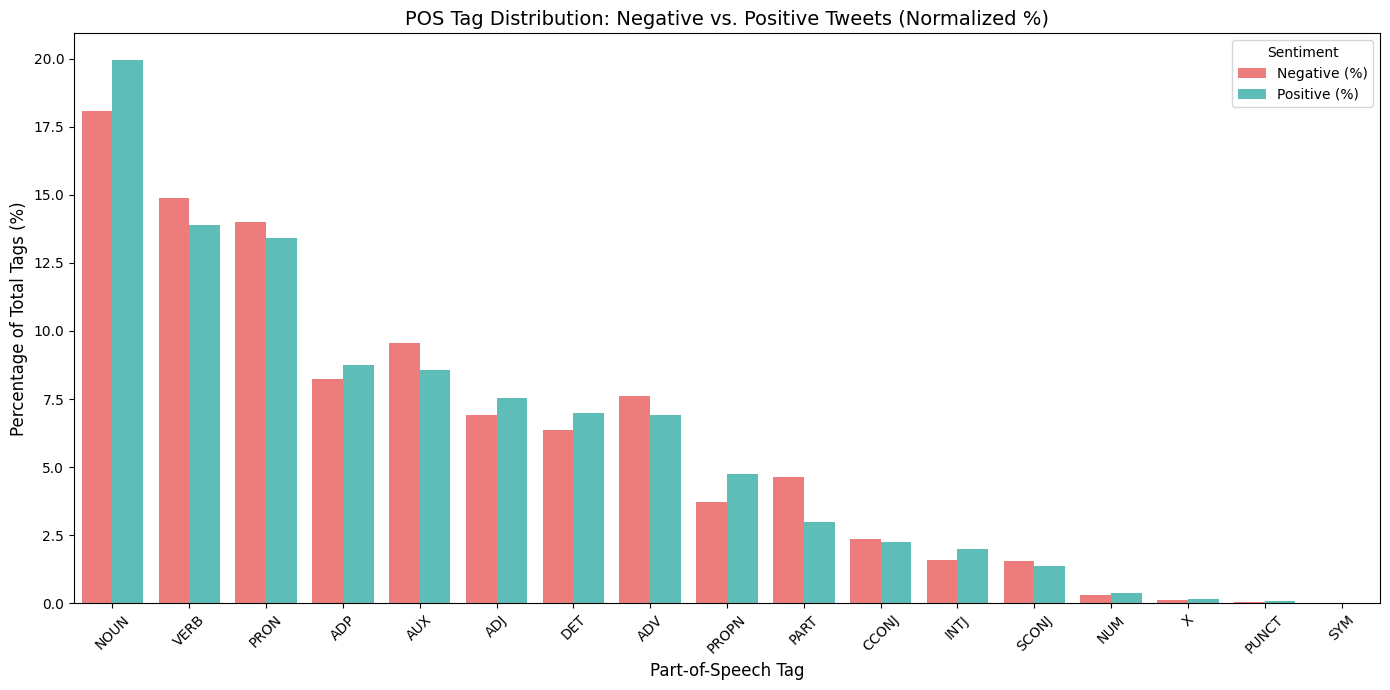

In [ ]:
# Melt the dataframe for easy seaborn plotting
melted_df = pos_comparison_df.melt(id_vars='POS_Tag',
                                   value_vars=['Negative (%)', 'Positive (%)'],
                                   var_name='Sentiment',
                                   value_name='Percentage')

plt.figure(figsize=(14, 7))
sns.barplot(data=melted_df, x='POS_Tag', y='Percentage', hue='Sentiment', palette=['#FF6B6B', '#4ECDC4'])
plt.title('POS Tag Distribution: Negative vs. Positive Tweets (Normalized %)', fontsize=14)
plt.xlabel('Part-of-Speech Tag', fontsize=12)
plt.ylabel('Percentage of Total Tags (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Top Differences in POS Usage ---")
pos_comparison_df['Difference (Pos - Neg)'] = pos_comparison_df['Positive (%)'] - pos_comparison_df['Negative (%)']
display(pos_comparison_df.sort_values(by='Difference (Pos - Neg)', ascending=False).head(10))


--- Top Differences in POS Usage ---


,POS_Tag,Negative (%),Positive (%),Difference (Pos - Neg)
10,NOUN,18.094612,19.939868,1.845256
13,PROPN,3.719079,4.760619,1.041539
4,ADJ,6.907689,7.543307,0.635618
7,DET,6.377961,7.000746,0.622786
15,ADP,8.230599,8.748069,0.517470
11,INTJ,1.601800,1.992497,0.390697
1,NUM,0.311247,0.367599,0.056352
6,X,0.116217,0.146483,0.030267
2,PUNCT,0.049277,0.066777,0.017500
9,SYM,0.001039,0.001309,0.000270


Based on the distribution graph and the tablar result shown above

**Dominant POS Tags**: Nouns, Verbs, and Pronouns are the most frequent across both sentiments, together making up roughly 50% of all tags.

**Positive Sentiment Indicators**: Positive tweets show a higher relative frequency of Nouns (+1.85%) and Interjections (+0.70%). This suggests positive content is more object-oriented and uses more expressive emotional fillers (e.g 'yay', 'wow').

**Negative Sentiment Indicators**: Negative tweets contain more Verbs (-0.98%) and Pronouns (-0.58%). This often corresponds to a focus on personal actions and self-referential complaints.

**Structural Similarity**: Most other tags (Adpositions, Auxiliaries, Adverbs) show very stable distributions across both classes, indicating the overall grammatical structure of tweets remains consistent regardless of sentiment.

### Discussion: How Noise Affects POS Tagging Accuracy

Social media text, specifically tweets, is extremely difficult for traditional NLP models to parse accurately. Here is how the noise inherent in this dataset degrades POS tagging performance:

1. **Missing Punctuation and Capitalization:** Standard POS taggers rely heavily on capitalization to detect Proper Nouns (`PROPN`) and punctuation (like periods) to identify sentence boundaries. Tweets often lack standard ending punctuation and capitalization, causing taggers to misinterpret sentence structures and proper nouns.
2. **Slang and Neologisms:** Words like "smh", "bae", or "lol" do not exist in a standard tagger's vocabulary. Because the tagger doesn't know they are interjections (`INTJ`) or adverbs, it defaults to tagging them as regular nouns (`NOUN`), leading to inaccurate syntax trees.
3. **Hashtags and Mentions:** While our pipeline cleaned these, in their raw form, a hashtag like `#SoGratefulToday` is a single token. Taggers often misclassify the whole construct, or if they split on the camel-case, they fail to understand the contextual grammar. Mentions (`@user`) are often misclassified as proper nouns when they act as pronouns (e.g., "Hey @user, come here" -> `@user` is a pronoun, not an entity).
4. **Elongated Words and Typos:** Words like "yesssss" or "looove" are Out-Of-Vocabulary (OOV) for standard dictionaries. The tagger cannot look them up, so it guesses based on suffixes, which frequently fails (e.g., it might tag "looove" as a noun instead of a verb).
5. **Emojis and Emoticons:** Without specific handling (like spaCy's emoji support), emoticons like `:)` or `:D` are treated as random punctuation groupings rather than expressions of emotion (which syntactically often function as adjectives or interjections).


#**Feature Engineering – Bag of Words & TF-IDF**

In [ ]:
class FeatureEngineer:
    """
    A modular class to extract BoW and TF-IDF features and analyze their properties.
    """
    def __init__(self, max_features=10000):
        self.max_features = max_features

    def extract_features(self, text_series):
        """
        Fits and transforms text data into BoW and TF-IDF sparse matrices.
        """
        # Initialize Vectorizers (using float32 to save memory on 1.6M rows)
        bow_vec = CountVectorizer(max_features=self.max_features, dtype=np.int32)
        tfidf_vec = TfidfVectorizer(max_features=self.max_features, dtype=np.float32)

        # Transform data
        X_bow = bow_vec.fit_transform(text_series)
        X_tfidf = tfidf_vec.fit_transform(text_series)

        return X_bow, X_tfidf, bow_vec, tfidf_vec

    def calculate_sparsity(self, matrix):
        """
        Calculates the sparsity percentage of a sparse matrix.
        Sparsity = % of zero values.
        """
        total_elements = matrix.shape[0] * matrix.shape[1]
        zero_elements = total_elements - matrix.nnz # nnz = number of non-zero elements
        return (zero_elements / total_elements) * 100

    def get_top_features(self, vectorizer, matrix, top_n=15):
        """
        Extracts the top N most frequent/highest weighted features.
        """
        # Sum the frequencies/weights across all documents (axis=0)
        feature_sums = np.array(matrix.sum(axis=0)).flatten()

        # Get indices of top features
        top_indices = feature_sums.argsort()[-top_n:][::-1]

        # Map indices to feature names
        feature_names = vectorizer.get_feature_names_out()
        return [(feature_names[i], feature_sums[i]) for i in top_indices]

    def analyze_version(self, version_name, text_series):
        """
        Full pipeline: Extract features, calculate metrics, and return structured results.
        """
        print(f"Extracting features for {version_name}...")

        # Drop empty strings that may result from aggressive cleaning
        clean_texts = text_series[text_series.str.strip() != '']

        # Extract
        X_bow, X_tfidf, bow_vec, tfidf_vec = self.extract_features(clean_texts)

        # Analyze
        metrics = {
            'Version': version_name,
            'Vocabulary Size': len(bow_vec.vocabulary_),
            'BoW Sparsity (%)': self.calculate_sparsity(X_bow),
            'TF-IDF Sparsity (%)': self.calculate_sparsity(X_tfidf),
            'Top BoW Features': self.get_top_features(bow_vec, X_bow, top_n=10),
            'Top TF-IDF Features': self.get_top_features(tfidf_vec, X_tfidf, top_n=10)
        }

        return metrics


In [ ]:
# Initialize Feature Engineer Class with 10000 as limit
engineer = FeatureEngineer(max_features=10000)

versions_to_test = {
    'Version A (Basic)': 'Version_A_Basic',
    'Version B (Stemming)': 'Version_B_Stem',
    'Version C (Lemmatization)': 'Version_C_Lemma'
}

results = []
for name, col in versions_to_test.items():
    metrics = engineer.analyze_version(name, df[col])
    results.append(metrics)

Extracting features for Version A (Basic)...
Extracting features for Version B (Stemming)...
Extracting features for Version C (Lemmatization)...


###Visualisation and Comparison

/tmp/ipykernel_8892/1430064032.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vocab_data, x='Version', y='Vocabulary Size', ax=axes[1], palette='Set3')


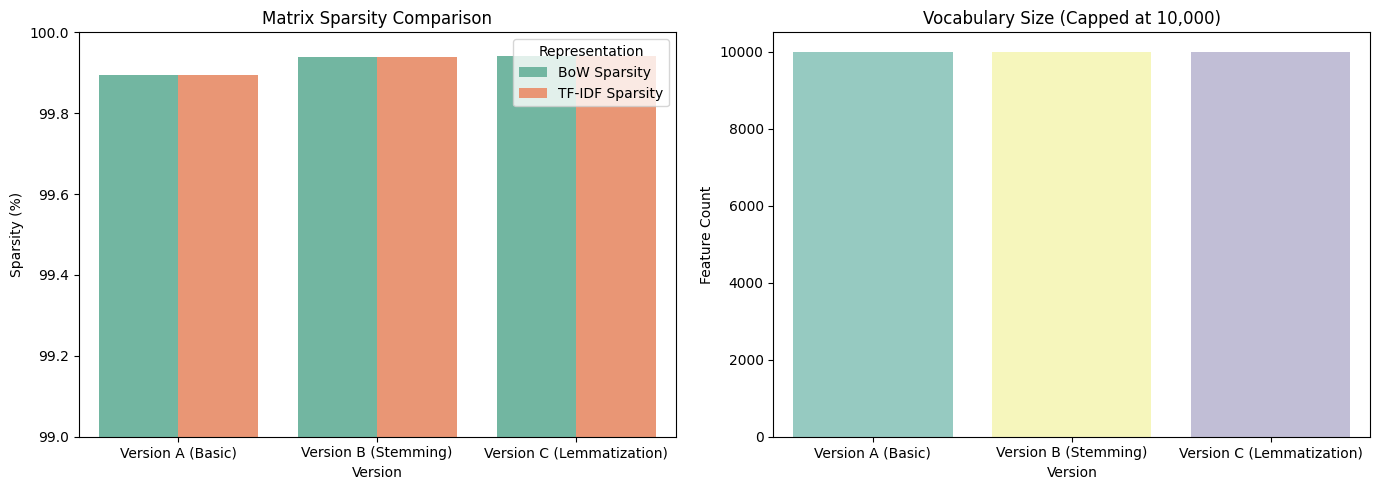

In [ ]:
# 1. Plot Sparsity & Vocabulary Size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sparsity Plot
sparsity_data = pd.DataFrame([{
    'Version': r['Version'],
    'BoW Sparsity': r['BoW Sparsity (%)'],
    'TF-IDF Sparsity': r['TF-IDF Sparsity (%)']
} for r in results])

sparsity_melted = sparsity_data.melt(id_vars='Version', var_name='Representation', value_name='Sparsity (%)')
sns.barplot(data=sparsity_melted, x='Version', y='Sparsity (%)', hue='Representation', ax=axes[0], palette='Set2')
axes[0].set_title('Matrix Sparsity Comparison')
axes[0].set_ylim(99.0, 100.0) # Sparsity is typically >99% for text

# Vocabulary Plot (Though limited to 10k, it shows how many actual unique words existed before capping)
vocab_data = pd.DataFrame([{'Version': r['Version'], 'Vocabulary Size': r['Vocabulary Size']} for r in results])
sns.barplot(data=vocab_data, x='Version', y='Vocabulary Size', ax=axes[1], palette='Set3')
axes[1].set_title('Vocabulary Size (Capped at 10,000)')
axes[1].set_ylabel('Feature Count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_8892/356576090.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
/tmp/ipykernel_8892/356576090.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
/tmp/ipykernel_8892/356576090.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')


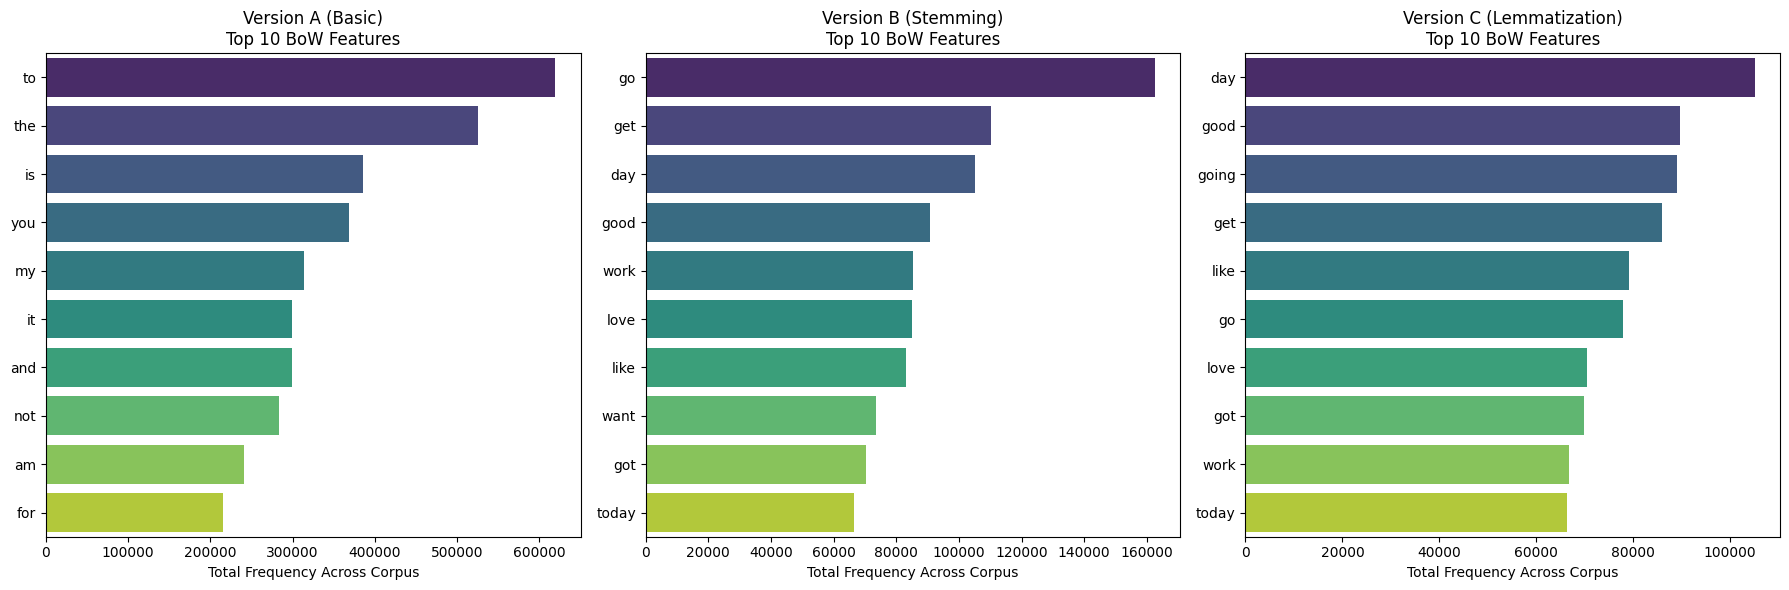

In [ ]:
#Plot Top Feature Quality (BoW)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, res in enumerate(results):
    top_feats = res['Top BoW Features']
    words = [x[0] for x in top_feats]
    counts = [x[1] for x in top_feats]

    sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
    axes[i].set_title(f"{res['Version']}\nTop 10 BoW Features")
    axes[i].set_xlabel('Total Frequency Across Corpus')

plt.tight_layout()
plt.show()


In [ ]:
#Print Summary Table
print("\n=== FEATURE ENGINEERING ANALYSIS SUMMARY ===")
summary_df = pd.DataFrame([{
    'Version': r['Version'],
    'Vocab Size': r['Vocabulary Size'],
    'BoW Sparsity (%)': round(r['BoW Sparsity (%)'], 4),
    'Top 3 BoW Words': [x[0] for x in r['Top BoW Features'][:3]]
} for r in results])

display(summary_df)


=== FEATURE ENGINEERING ANALYSIS SUMMARY ===


,Version,Vocab Size,BoW Sparsity (%),Top 3 BoW Words
0,Version A (Basic),10000,99.8941,"[to, the, is]"
1,Version B (Stemming),10000,99.9397,"[go, get, day]"
2,Version C (Lemmatization),10000,99.9409,"[day, good, going]"


#**Analysis and Reflection**

### i. Challenges Encountered Due to the Noisy Nature of Twitter Data

Working with the Sentiment140 dataset revealed that social media text operates under entirely different linguistic rules than formal text, presenting several distinct challenges:
*  As identified in data exploratory anaysis section, the sheer volume of noise, URLs, user mentions (`@user`), hashtags (`#topic`), and emojis expands the feature space exponentially. Without cleaning, vectorizers waste thousands of features simply capturing unique URLs or mention handles that act as unique identifiers rather than sentiment indicators.
*  Twitter users emphasize emotion through irregular casing ("SO MAD"), repeated characters ("yesssss"), and excessive punctuation ("!!!"). While these carry sentiment, standard NLP models treat "yes" and "yesssss" as completely unrelated tokens, severely fragmenting the vocabulary.
*  As observed in POS Tagging, the lack of standard punctuation and capitalization breaks sentence boundary detection. Slang ("smh", "lol") and misspellings are treated as Out-Of-Vocabulary (OOV) nouns, causing POS taggers to misclassify them and fail to capture the syntactic structure of the tweet.
*  Phrases like "can't" or "im" require specialized handling. If punctuation is stripped before contractions are expanded, "don't" becomes "dont", which standard dictionaries cannot interpret, losing the vital "not" token that flips sentiment.

### ii. Differences Between Stemming and Lemmatization on This Dataset

During the text preprocessing, Version B (Stemming) and Version C (Lemmatization) treated the same base text differently, leading to distinct outputs highly visible in the feature analysis section:
* Stemming (Porter) uses heuristic rules to chop suffixes. On this dataset, it frequently created non-words or stripped crucial sentiment nuance (e.g., "better" to "bet", "going" to "go"). Lemmatization (WordNet), conversely, mapped words to actual dictionary roots, preserving meaning (e.g., "better" to "good", "mice" to "mouse").
* Stemming mindlessly applied rules to slang (e.g., "lol" remained "lol", "happening" to "happen"). Lemmatization attempted to resolve slang to known roots, though it often failed on heavy slang, leaving it as-is.
* As seen in the Top Features plot, Version B's top features included fragmented stems, making post-hoc analysis difficult. Version C's top features consisted entirely of valid English words, making it much easier to interpret why a model makes a specific sentiment prediction.

### iii. Effect of Preprocessing on Vocabulary Reduction and Data Quality

The progression from Version A to Versions B/C demonstrated a massive shift in both the volume and the usefulness of the data:
*  Version A (Basic Cleaning) retained high-frequency, low-value stopwords ("the", "to", "i"). Because our `max_features` was capped at 10,000, these stopwords crowded out rarer, sentiment-bearing words. Versions B and C eliminated stopwords, allowing the 10,000 feature limit to be entirely occupied by content-rich nouns, verbs, and adjectives.
* Matrix sparsity marginally *increased* from Version A to B/C. In Version A, stopwords appeared in almost every tweet, making the matrix slightly denser. In B/C, the remaining content words are rarer, creating more zeros. However, this increased sparsity is highly desirable because we traded uniform noise for sparse, high-signal features.
* The most profound impact was on feature quality. The features visualizations proved that Version A's BoW was dominated by function words useless for sentiment classification. Versions B/C shifted the top features to words like "love", "good", and "happy", these are tokens with direct, unambiguous correlations to positive and negative sentiment.

### iv. Recommended Preprocessing Strategy for Downstream Sentiment Classification

For downstream sentiment classification, I recommend **Version C: Full Cleaning + Stopword Removal + Lemmatization**.

**Justification:**
1. Sentiment is often carried by nuanced adjectives and adverbs. Stemming aggressively truncates these, sometimes merging words with different sentiments into the same root. Lemmatization preserves the semantic integrity of the text, ensuring that "worse" and "bad" are properly mapped to their distinct roots, giving the classifier precise features.
2. By combining lemmatization with stopword and noise removal, we condense the vocabulary to its most informative core. The classifier won't waste parameters learning that the word "the" appears in both positive and negative tweets; it will focus its weights on highly polarized words like "terrible" or "awesome".
3. Lemmatization yields human-readable features. If a logistic regression model weights the feature "hate" highly, it is instantly interpretable. If it weights the stem "hat", interpretability is lost.
4. The full pipeline (contraction expansion, repeated character reduction, URL removal) ensures that the classifier receives a standardized, clean input. A tweet reading "I LOOOOVE this!!! http://t.co/xyz" and a tweet reading "I love this" are correctly mapped to the exact same feature space, preventing the model from overfitting to stylistic noise.